
## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r'C:\Users\ASUS\Desktop\churn-prediction')
print(os.getcwd())  # confirm it's the project root

C:\Users\ASUS\Desktop\churn-prediction


## 2. Load Raw Data

In [3]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [7]:
df['Churn'].value_counts(normalize=True) * 100  # check class imbalance

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## 3. Data Cleaning

**TotalCharges** was loaded as text (object) instead of numeric, because 11 rows contain a blank space `' '` instead of a number — these are customers with `tenure = 0` (brand new, no charges yet).

In [8]:
df[df['TotalCharges'] == ' ']  # inspect the problem rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # blanks become NaN

In [10]:
df['TotalCharges'].isna().sum()  # confirm 11 NaNs

np.int64(11)

In [11]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # fill with 0 (no charges yet)

In [12]:
df['TotalCharges'].dtype  # confirm now float64

dtype('float64')

## 4. Save Checkpoint
Save the cleaned dataframe so future sessions can reload instantly without re-running cleaning steps.

In [13]:
os.makedirs('data', exist_ok=True)
df.to_pickle('data/cleaned_churn_data.pkl')

## 5. EDA 

**Reload point:** if you're starting a new session, run the cell below instead of Sections 1-4 above.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r'C:\Users\ASUS\Desktop\churn-prediction')
df = pd.read_pickle('data/cleaned_churn_data.pkl')

### 5.1 Churn Rate by Contract Type

In [15]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


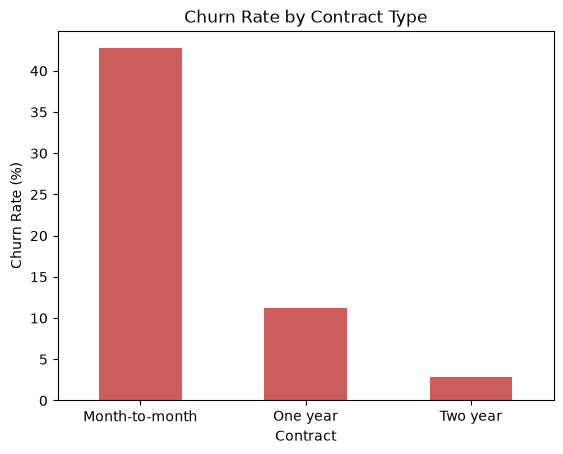

In [16]:
contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='indianred')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.savefig('images/churn_by_contract.png', bbox_inches='tight')
plt.show()

**Finding:** Month-to-month customers churn at 42.7%, vs 11.3% for one-year and just 2.8% for two-year contracts.

**Implication:** Contract length is one of the strongest churn predictors in this dataset. Customers with no lock-in have far less friction to leave. This suggests the business could reduce churn significantly by incentivizing upgrades from month-to-month to annual/two-year plans-e.g. discounts for longer commitments, bundling perks, or proactive retention offers targeted specifically at the month-to-month segment (since that's also likely the largest group by volume).

### 5.2 Churn vs Tenure

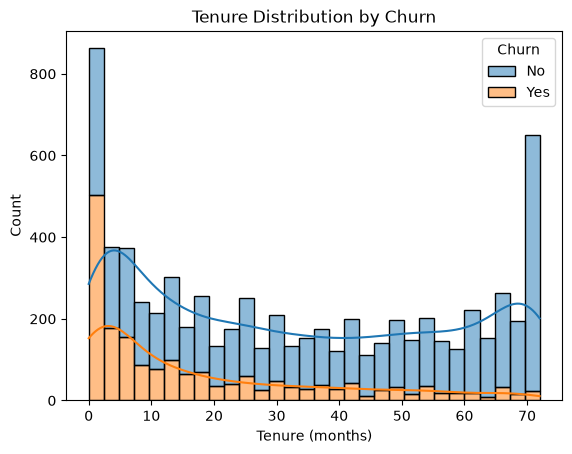

In [17]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, multiple='stack')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.savefig('images/tenure_by_churn.png', bbox_inches='tight')
plt.show()

**Finding:** Churn is heavily concentrated among low-tenure customers (first few months). Customers who reach 5-6 years of tenure churn almost never.

**Implication:** The highest-risk window is the early relationship period. Investing in onboarding/early engagement is likely more impactful than targeting already-loyal, long-tenure customers. Possibly linked to Contract Type finding above-new customers are likely disproportionately month-to-month.

### 5.3 Churn vs Monthly Charges


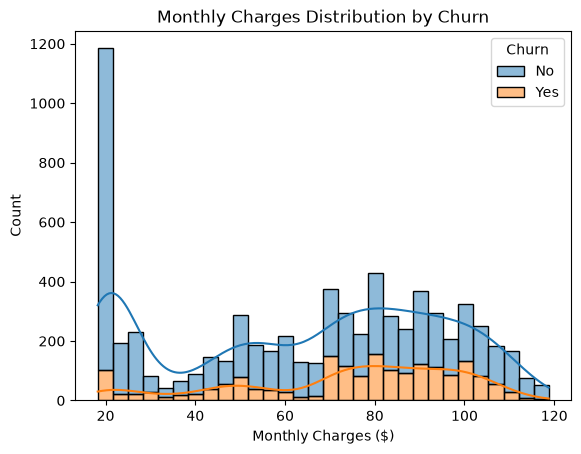

In [18]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, multiple='stack')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.savefig('images/charges_by_churn.png', bbox_inches='tight')
plt.show()

**Finding**: Churn is proportionally concentrated among customers with higher monthly charges (~$70-100/month), while very low-bill customers (~$20, likely single-service subscribers) show minimal churn.

**Implication**: Customers with larger bills may feel they're not getting proportional value, or higher charges may correlate with bundled add-on services (e.g. streaming, security) that aren't sticky. This ties into Contract Type and Tenure too-worth checking later whether high-monthly-charge customers are disproportionately month-to-month and low-tenure, which would suggest it's really one combined risk profile (new + uncommitted + expensive) rather than three separate factors.

### 5.4 Monthly Charges — Boxplot View

A boxplot gives a more compact comparison of the two groups' charge distributions-median, spread, and outliers at a glance, alongside the histogram above.

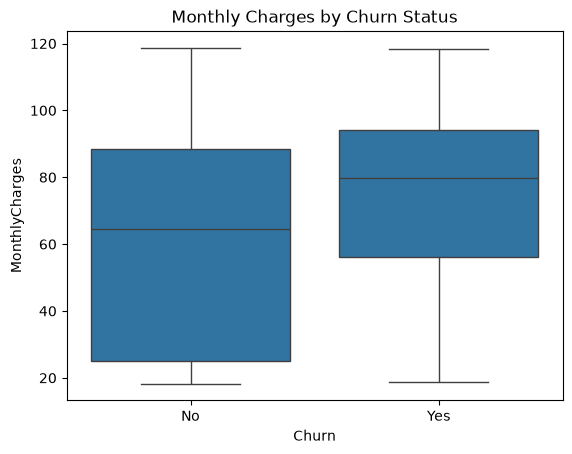

In [19]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.savefig('images/charges_boxplot.png', bbox_inches='tight')
plt.show()

**Finding**: Churned customers have a higher median monthly charge (~$80) than retained customers (~$65), and their charges are more tightly clustered in the $57-94 range while retained customers span a much wider range including many low-charge customers.

**Implication**: Confirms the histogram higher monthly charges are associated with higher churn risk. Retained customers include a large low-cost segment (likely single-service subscribers) who rarely leave. This strengthens the earlier hypothesis: churn risk may cluster around a specific customer profile new, month-to-month, higher-paying rather than being three unrelated factors.

### 5.5 Churn by Internet Service

In [20]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


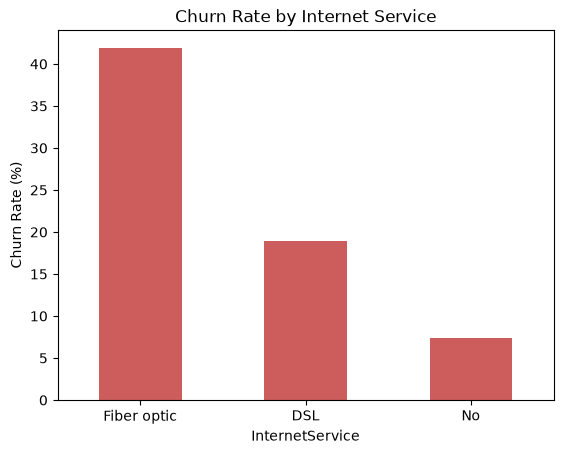

In [21]:
internet_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='indianred')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.savefig('images/churn_by_internet.png', bbox_inches='tight')
plt.show()

**Finding**: Customers with Fiber optic internet churn at ~42%, roughly 2.2x the rate of DSL customers (~19%) and nearly 6x customers with no internet service (~7%).

**Implication**: This is counterintuitive at first Fiber is usually the "premium" product but it likely connects to your Monthly Charges finding: fiber plans are typically the most expensive tier, so this may be less about the technology itself and more about price sensitivity and perceived value. It's also worth considering service quality/reliability complaints as a possible cause, though the data alone can't confirm that worth flagging as a question rather than a conclusion. Customers with no internet (phone-only) are the most stable segment, likely because they're a low-cost, low-complexity relationship.

### 5.6 Churn by Tech Support

In [22]:
techsupport_churn = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


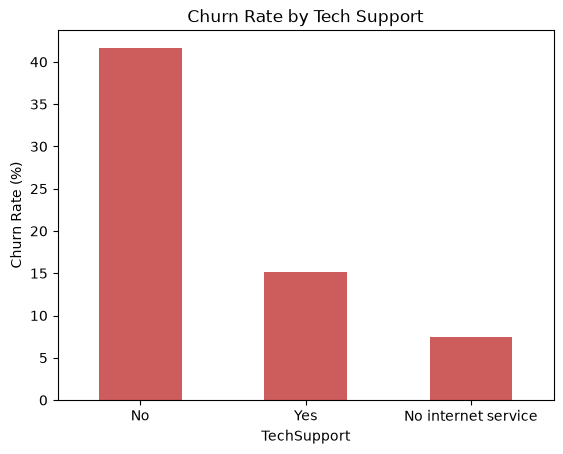

In [23]:
techsupport_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='indianred')
plt.title('Churn Rate by Tech Support')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.savefig('images/churn_by_techsupport.png', bbox_inches='tight')
plt.show()

**Finding**: Customers without Tech Support churn at ~42%, nearly 3x the rate of customers who have Tech Support (~15%).

**Implication**: This is one of your most actionable findings so far unlike contract type or tenure (which are harder to change once a customer signs up), Tech Support is an add-on service the business can actively upsell or bundle. Proactively offering free/discounted tech support to at-risk customers (e.g. new, month-to-month, fiber customers) could be a concrete retention lever, not just a description of who churns.

## 6. Week 2 EDA-Summary of Findings

1. **Contract Type:** Month-to-month customers churn at 42.7%, vs 11.3% (one-year) and 2.8% (two-year). Strongest single predictor found so far.
2. **Tenure:** Churn is concentrated in the first few months of the customer relationship; customers with 5-6+ years tenure rarely churn.
3. **Monthly Charges:** Churned customers have a higher median monthly charge (~$80) vs retained customers (~$65).
4. **Internet Service:** Fiber optic customers churn at ~42%, vs ~19% (DSL) and ~7% (no internet).
5. **Tech Support:** Customers without Tech Support churn at ~42%, vs ~15% for those with it an actionable retention lever.

**Overall pattern:** Churn risk clusters around a specific profile new, month-to-month, fiber optic, high monthly charges, no tech support rather than being driven by unrelated, independent factors. This suggests both a *predictive* opportunity (these features should be strong model inputs) and a *business* opportunity (proactive retention targeting this profile, e.g. tech support bundling or contract upgrade incentives).

## 7. Numeric Feature Correlation Check

In [24]:
numeric_cols = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
corr_matrix = numeric_cols.corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


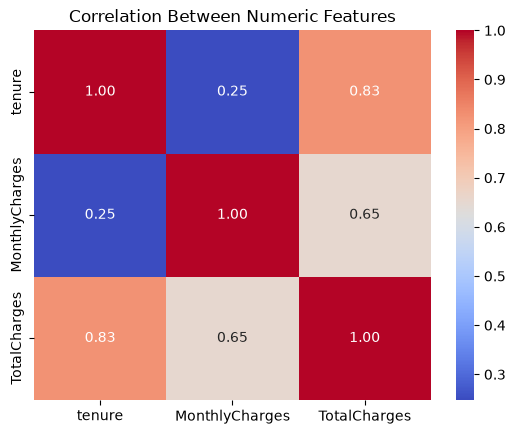

In [25]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.savefig('images/numeric_correlation.png', bbox_inches='tight')
plt.show()

**Finding:** TotalCharges is strongly correlated with tenure (0.83) and moderately with MonthlyCharges (0.65), while tenure and MonthlyCharges themselves are only weakly related (0.25).

**Implication:** TotalCharges carries largely redundant information (multicollinearity). This should be addressed during feature engineering — e.g. by dropping TotalCharges, or engineering a derived ratio feature instead — particularly if a linear model is used.

## 8. Feature Engineering

This section addresses issues identified during EDA before modeling begins.

### 8.1 Resolving Multicollinearity-Dropping TotalCharges

`TotalCharges` is highly correlated with `tenure` (0.83) and `MonthlyCharges` (0.65) 
and adds little independent predictive value. Dropping it keeps the feature set 
interpretable and avoids unstable model coefficients later.

In [26]:
df_fe =df.drop(columns=['TotalCharges'])  # drop TotalCharges 

### 8.2 Encoding Categorical Variables

Machine learning models require numeric input, so categorical columns need to be 
converted before modeling. The encoding method depends on the nature of each 
category: binary columns get simple 0/1 encoding, unordered multi-category columns 
get one-hot encoding, and ordered categories (like `Contract`) get ordinal encoding 
to preserve their natural ranking.

In [27]:
df_fe.select_dtypes(include='object').columns.tolist()  # check categorical columns

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8640\1359578506.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_fe.select_dtypes(include='object').columns.tolist()  # check categorical columns


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [28]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    print(col, df_fe[col].unique())

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PaperlessBilling <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Churn <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [29]:
df_fe['gender'] = df_fe['gender'].map({'Female': 0, 'Male': 1})

yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in yes_no_cols:
    df_fe[col] = df_fe[col].map({'No': 0, 'Yes': 1})

In [30]:
df_fe[['gender'] + yes_no_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [31]:
df_fe['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

In [32]:
df_fe['Contract'] = df_fe['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

In [33]:
df_fe['Contract'].value_counts()

Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64

In [34]:
onehot_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
               'PaymentMethod']

df_fe = pd.get_dummies(df_fe, columns=onehot_cols, drop_first=False)

In [35]:
df_fe.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'Churn',
 'MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'PaymentMethod_Bank transfer (automatic)',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [36]:
df_de=df_fe.drop(columns=['customerID'])  # drop customerID

In [37]:
df_fe['SeniorCitizen'].unique()

array([0, 1])

In [38]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   str    
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   Contract                                 7043 non-null   int64  
 8   PaperlessBilling                         7043 non-null   int64  
 9   MonthlyCharges                           7043 non-null   float64
 10  Churn                                    7043 non-null   in

In [39]:
df_fe = df_fe.drop(columns=['customerID'])

In [40]:
bool_cols = df_fe.select_dtypes(include='bool').columns
df_fe[bool_cols] = df_fe[bool_cols].astype(int)

In [41]:
df_fe.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   Contract                                 7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   MonthlyCharges                           7043 non-null   float64
 9   Churn                                    7043 non-null   int64  
 10  MultipleLines_No                         7043 non-null   in

In [42]:
df_fe.to_pickle('data/feature_engineered_churn_data.pkl')

### 8.3 Feature Scaling : Moved to Modeling Phase

Scaling was intentionally deferred to the modeling phase to avoid data leakage. 
Standard practice is to fit the scaler only on training data after the 
train/test split, not on the full dataset beforehand. See modeling notebook 
section for implementation.